# Limpeza e agrupamento dos espectros

Neste notebook, iremos filtrar os espectros para utilizar apenas os confiáveis para fazer a média. 
 * A partir da medida do fluxo e do erro em 5500, calculamos o SNR e selecionamos apenas aqueles com SNR > 2.
 * Também iremos excluir aqueles em que o erro em 5500 ficou acima de 1.1.
Outro fator a se considerar são os espectros duplicados. Quando mais de um espectro estiver disponível para o mesmo LRD, iremos utilizar o com maior SRN, e excluir os outros.

Os grupos foram divididos de acordo com o fluxo em 5500, da seguinte forma:
 * G1: entre 0 e 1.25
 * G2: entre 1.25 e 2.5
 * G3: entre 2.5 e 3.75
 * G4: entre 3.75 e 5
 * G5: entre 5 e 6.5
 * The Cliff como um caso isolado

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
## importing libraries
from functions import load_spectrum, plot_spectrum_ax, make_spectrum_panel, compute_error_stats, plot_overlaid_spectra, plot_spectrum_presentation, plot_spectrum_shaded_lines, compute_mean_spectrum, plot_mean_spectrum, plot_overlaid_mean_spectra
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import pandas as pd
from astropy.table import Table

pd.set_option('display.max_columns', 50)

## Importando dados

In [68]:
hdul = fits.open("deGraaff2025_lrds_withdups_blackbody_eline_fits.fits")
hdul.info()
data = hdul[1].data

files = data["file"]
redshifts = data["zspec"]

#transforming into numpy arrays
files = np.array(files)
redshifts = np.array(redshifts)

print(redshifts.min(), redshifts.max())

spec_info_all = list(zip(files, redshifts))

#removing info from the spectra of program MoM (GO5224) since we don't have its spectra
spec_info_clear = spec_info_all[:59] + spec_info_all[72:]
print(len(spec_info_clear))
print(spec_info_clear[:10])


Filename: deGraaff2025_lrds_withdups_blackbody_eline_fits.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOT          1 BinTableHDU     94   134R x 32C   [K, K, 24A, 57A, D, D, D, D, D, K, 196A, L, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D]   


2.2734878 9.294025001594942
121
[(np.str_('capers-cos07-v4_prism-clear_6368_43711.spec.fits'), np.float64(4.42044)), (np.str_('capers-cos10-v4_prism-clear_6368_119334.spec.fits'), np.float64(9.294025001594942)), (np.str_('capers-cos10-v4_prism-clear_6368_30440.spec.fits'), np.float64(3.5045)), (np.str_('capers-cos10-v4_prism-clear_6368_32659.spec.fits'), np.float64(4.44217)), (np.str_('capers-cos13-v4_prism-clear_6368_160387.spec.fits'), np.float64(6.38003)), (np.str_('capers-cos19-v4_prism-clear_6368_4771.spec.fits'), np.float64(5.92735)), (np.str_('capers-cos19-v4_prism-clear_6368_9226.spec.fits'), np.float64(3.7241027)), (np.str_('capers-egs47-v4_prism-clear_6368_19300.spec.fits'), np.float64(4.5332627)), (np.str_('capers-egs47-v4_prism-clear_6368_212932.spec.fits'), np.float64(2.28602)), (np.str_('capers-egs49-v4_prism-clear_6368_11585.spec.fits'), np.float64(6.6958222))]


In [69]:
table = Table.read("deGraaff2025_lrds_withdups_blackbody_eline_fits.fits")

data = {}

for col in table.colnames:
    arr = np.array(table[col])

    if arr.ndim == 1:
        data[col] = arr
    else:
        for i in range(arr.shape[1]):
            data[f"{col}_{i}"] = arr[:, i]

degraaff = pd.DataFrame(data)

## decodificar a coluna file
degraaff['root'] = degraaff['root'].str.decode("utf-8")
degraaff["file"] = degraaff["file"].str.decode("utf-8")

degraaff


,pid,srcid,root,file,ra,dec,zspec,f444w_aper0.1,mu,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,use_dG25,lambda_v_0,lambda_v_1,lambda_v_2,lambda_v_3,lambda_v_4,beta_UV_0,beta_UV_1,beta_UV_2,beta_UV_3,beta_UV_4,...,OIII_5007_ew_0,OIII_5007_ew_1,OIII_5007_ew_2,OIII_5007_ew_3,OIII_5007_ew_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logLOIII_5007_0,logLOIII_5007_1,logLOIII_5007_2,logLOIII_5007_3,logLOIII_5007_4,LOI_8446_0,LOI_8446_1,LOI_8446_2,LOI_8446_3,LOI_8446_4,logLOI_8446_0,logLOI_8446_1,logLOI_8446_2,logLOI_8446_3,logLOI_8446_4
0,6368,43711,capers-cos07-v4,capers-cos07-v4_prism-clear_6368_43711.spec.fits,150.102626,2.249597,4.420440,181.549630,1.000000,0,b'None',b'None',b'None',b'None',True,0.425702,0.430078,0.441872,0.453769,0.457348,-1.503000,-1.472940,-1.431095,-1.388518,-1.357008,...,636.297685,643.992119,659.556344,673.612876,685.251929,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,42.602089,42.604191,42.608112,42.611892,42.614373,1.204418e+41,1.329451e+41,1.518157e+41,1.713626e+41,1.848623e+41,41.080777,41.123672,41.181317,41.233916,41.266848
1,6368,119334,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_119334.spec.fits,150.136253,2.308030,9.294025,55.454540,1.000000,0,b'None',b'None',b'None',b'None',True,0.295844,0.297898,0.299323,0.300055,0.300263,-0.683087,-0.588453,-0.436385,-0.292621,-0.222977,...,10.321968,13.622837,18.650406,23.797464,27.807140,2.476371e+41,3.258825e+41,4.353137e+41,5.529167e+41,6.301914e+41,41.393814,41.513059,41.638802,41.742660,41.799472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6368,30440,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_30440.spec.fits,150.120910,2.317934,3.504500,158.032135,1.000000,0,b'None',b'None',b'None',b'None',True,0.390295,0.446067,0.490416,0.513559,0.534144,-1.601198,-1.541400,-1.443985,-1.356757,-1.301895,...,1144.136261,1194.063640,1265.382709,1340.476041,1392.708499,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.287998,42.293137,42.298936,42.306263,42.309765,1.215027e+41,1.299733e+41,1.428087e+41,1.560501e+41,1.660314e+41,41.084586,41.113854,41.154755,41.193264,41.220190
3,6368,32659,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_32659.spec.fits,150.124025,2.306827,4.442170,48.655941,1.000000,0,b'None',b'None',b'None',b'None',True,0.355072,0.369303,0.415672,0.479048,0.503339,-1.969952,-1.753011,-1.485526,-1.255769,-1.093699,...,360.579801,372.366274,395.787444,426.620781,443.276297,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,41.752262,41.759622,41.772262,41.784559,41.793809,5.702253e+39,1.479514e+40,3.043077e+40,4.748942e+40,5.941310e+40,39.881385,40.192852,40.488408,40.677228,40.774987
4,6368,160387,capers-cos13-v4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,150.129404,2.393668,6.380030,20.098543,1.000000,0,b'None',b'None',b'None',b'None',True,0.344155,0.352944,0.391064,0.410516,0.418669,-2.226727,-1.954039,-1.704844,-1.481515,-1.314637,...,825.141124,979.922379,1248.876513,1789.196289,2660.391479,1.406226e+42,1.450743e+42,1.513514e+42,1.583113e+42,1.627397e+42,42.148055,42.161591,42.179986,42.199512,42.211493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2561,28876,uncover-v4,uncover-v4_prism-clear_2561_28876.spec.fits,3.569597,-30.373223,7.036244,32.379270,3.107558,0,b'None',b'None',b'None',b'None',True,0.362279,0.368760,0.388185,0.408302,0.416098,-2.126495,-2.037579,-1.899684,-1.776560,-1.695117,...,18.477201,21.256300,25.340737,29.859528,32.639900,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,40.953137,41.022356,41.094416,41.161823,41.197883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,2561,38108,uncover-v4,uncover-v4_prism-clear_2561_38108.spec.fits,3.530009,-30.358013,4.968462,219.578945,2.247872,0,b'None',b'None',b'None'

In [70]:
### Criando um DataFrame para armazenar as estatísticas dos espectros

rows = []

for fname, z in spec_info_clear:
    spec = load_spectrum(
        f"DeGraaff_espectros/{fname}",
        z=z,
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window=(0.3446,0.3646)
    )

    stats = compute_error_stats(
        spec["wave"],
        spec['flux'],
        spec["err"],   # já normalizado
        window=(0.5400, 0.5600),
        normalized=spec["normalized"]
    )

    stats_2000 = compute_error_stats(
        spec["wave"],
        spec['flux'],
        spec["err"],   # já normalizado
        window=(0.1850, 0.2150),
        normalized=spec["normalized"]
    )

    rows.append({
        "file": fname,
        "z": z,
        "normalized": spec["normalized"],
        "norm_factor": spec["norm_factor"],
        "norm_window_min": (
            spec["norm_window"][0] if spec["norm_window"] else np.nan
        ),
        "norm_window_max": (
            spec["norm_window"][1] if spec["norm_window"] else np.nan
        ),
        "norm_error": spec["norm_error"],
        "err_norm_mean": spec["norm_err_mean"],
        "err_norm_median": spec["norm_err_median"],
        'flux_mean_5500': stats['flux_mean'],
        "err_mean_5500": stats["err_mean"],
        'flux_mean_2000': stats_2000['flux_mean'],
        'err_mean_2000': stats_2000['err_mean']
    })

df = pd.DataFrame(rows)
df["SNR_5500"] = df['flux_mean_5500'] / df['err_mean_5500']
df


/home/bruna/Documentos/Doutorado/LRDs/functions/spectrum.py:143: RuntimeWarning: All-NaN slice encountered
  norm_factor = np.nanmedian(flux[mask])


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270
1,capers-cos10-v4_prism-clear_6368_119334.spec.fits,9.294025,True,5.474831e-21,0.3446,0.3646,None,0.539672,0.517730,NaN,NaN,2.133456,0.927736,NaN
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564
117,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803
118,uncover-v4_prism-clear_2561_4286.spec.fits,5.835225,True,1.477175e-20,0.3446,0.3646,None,0.211924,0.209767,2.109584,0.191743,2.376764,0.444287,11.002120
119,uncover-v4_prism-clear_2561_45924.spec.fits,4.463361,True,1.373611e-19,0.3446,0.3646,None,0.011606,0.011611,3.433032,0.014499,1.875923,0.025443,236.778765


### Juntando informações do catalogo com os dados que obtivemos dos especttros

In [71]:

## decodificar a colunas 
degraaff['dup_filenames_0'] = degraaff['dup_filenames_0'].str.decode("utf-8")
degraaff['dup_filenames_1'] = degraaff['dup_filenames_1'].str.decode("utf-8")
degraaff['dup_filenames_2'] = degraaff['dup_filenames_2'].str.decode("utf-8")
degraaff['dup_filenames_3'] = degraaff['dup_filenames_3'].str.decode("utf-8")

## colunas de interesse
## criar uma tabela apenas com colunas de interesse

colunas_de_interesse = [ 'file', 'ra', 'dec', 'zspec',
                    'Ndup', 'dup_filenames_0', 'dup_filenames_1','dup_filenames_2','dup_filenames_3',
]

df_subset = degraaff[colunas_de_interesse].copy()
df_subset


,file,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,150.102626,2.249597,4.420440,0,None,None,None,None
1,capers-cos10-v4_prism-clear_6368_119334.spec.fits,150.136253,2.308030,9.294025,0,None,None,None,None
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,150.120910,2.317934,3.504500,0,None,None,None,None
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,150.124025,2.306827,4.442170,0,None,None,None,None
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,150.129404,2.393668,6.380030,0,None,None,None,None
...,...,...,...,...,...,...,...,...,...
129,uncover-v4_prism-clear_2561_28876.spec.fits,3.569597,-30.373223,7.036244,0,None,None,None,None
130,uncover-v4_prism-clear_2561_38108.spec.fits,3.530009,-30.358013,4.968462,0,None,None,None,None
131,uncover-v4_prism-clear_2561_4286.spec.fits,3.619201,-30.423270,5.835225,0,None,None,None,None
132,uncover-v4_prism-clear_2561_45924.spec.fits,3.584760,-30.343628,4.463361,1,uncover-v4_prism-clear_2561_45924.spec.fits,uncover-62-v4_prism-clear_2561_58453.spec.fits,None,None


In [72]:
## fazendo o merge entre os dois dataframes

df_merged = df.merge(df_subset, on="file")
df_merged

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,150.102626,2.249597,4.420440,0,None,None,None,None
1,capers-cos10-v4_prism-clear_6368_119334.spec.fits,9.294025,True,5.474831e-21,0.3446,0.3646,None,0.539672,0.517730,NaN,NaN,2.133456,0.927736,NaN,150.136253,2.308030,9.294025,0,None,None,None,None
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,150.120910,2.317934,3.504500,0,None,None,None,None
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,150.124025,2.306827,4.442170,0,None,None,None,None
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903,150.129404,2.393668,6.380030,0,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,3.569597,-30.373223,7.036244,0,None,None,None,None
117,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803,3.530009,-30.358013,4.968462,0,None,None,None,None
118,uncover-v4_prism-clear_2561_4286.spec.fits,5.835225,True,1.477175e-20,0.3446,0.3646,None,0.211924,0.209767,2.109584,0.191743,2.376764,0.444287,11.002120,3.619201,-30.423270,5.835225,0,None,None,None,None
119,uncover-v4_prism-clear_2561_45924.spec.fits,4.463361,True,1.373611e-19,0.3446,0.3646,None,0.011606,0.011611,3.433032,0.014499,1.875923,0.025443,236.778765,3.584760,-30.343628,4.463361,1,uncover-v4_prism-clear_2561_45924.spec.fits,uncover-62-v4_prism-clear_2561_58453.spec.fits,None,None


## Limpeza dos dados

<Axes: xlabel='err_mean_2000', ylabel='err_mean_5500'>

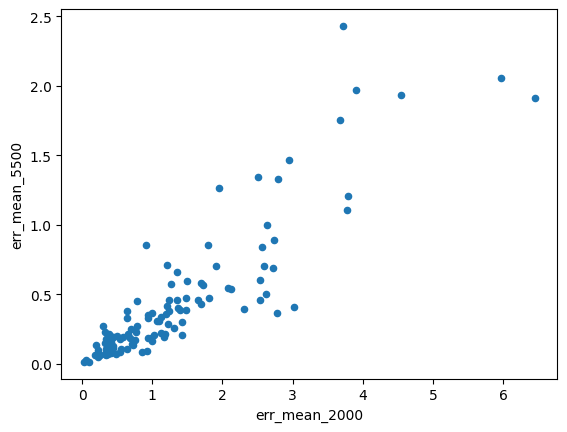

In [73]:
df_merged.plot.scatter('err_mean_2000', 'err_mean_5500')

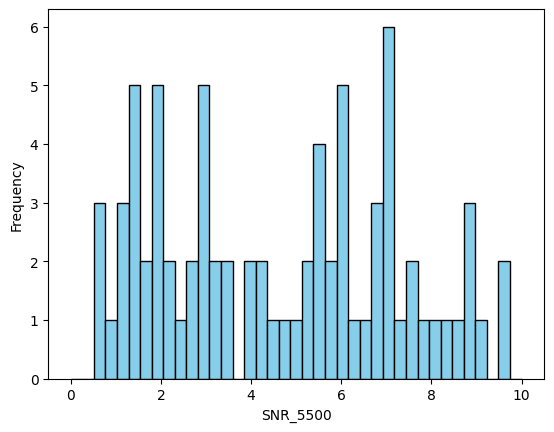

In [74]:
# Create the histogram
plt.hist(df_merged['SNR_5500'], bins=np.linspace(0, 10, 40), color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('SNR_5500')
plt.ylabel('Frequency')
#plt.title('')

plt.show()

### Filtros para SNR e erro em 5500

In [75]:
## objetos com SNR < 2
rfiltro_SNR_2 = df_merged['SNR_5500'] < 2
df_retirado_snr = df_merged[rfiltro_SNR_2]
df_retirado_snr


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903,150.129404,2.393668,6.380030,0,None,None,None,None
19,ceers-ddt-v4_prism-clear_2750_2015.spec.fits,4.892552,True,1.566177e-21,0.3446,0.3646,None,1.659204,1.641548,1.612301,1.109079,3.848120,3.772544,1.453730,214.917995,52.937245,4.892552,0,None,None,None,None
24,cosmos-transients-v4_prism-clear_6585_65449.sp...,5.205048,True,4.477463e-21,0.3446,0.3646,None,1.024578,1.006113,0.449430,0.605267,0.969053,2.535839,0.742532,150.132193,2.380441,5.205048,0,None,None,None,None
54,macs0416-v4_prism-clear_1208_3104219.spec.fits,6.414142,True,8.517997e-21,0.3446,0.3646,None,1.035353,1.031689,1.276079,0.999825,4.046941,2.639844,1.276303,64.068374,-24.112313,6.414142,0,None,None,None,None
55,macs0417-v4_prism-clear_1208_205006.spec.fits,5.621284,True,8.924223e-21,0.3446,0.3646,None,0.898028,0.898843,0.366699,0.706677,1.402662,1.911706,0.518905,64.376038,-11.798177,5.621284,0,None,None,None,None
57,macs1423-v4_prism-clear_1208_4111584.spec.fits,4.065684,True,7.675337e-21,0.3446,0.3646,None,0.881759,0.886041,0.712632,0.456509,2.709648,2.535624,1.561049,215.929628,24.108352,4.065684,0,None,None,None,None
61,nexus-obs3-v4_prism-clear_5105_12143.spec.fits,5.867350,True,1.970059e-20,0.3446,0.3646,None,0.672495,0.654349,0.867351,0.594056,2.202868,1.494477,1.460051,268.428339,65.173502,5.867350,0,None,None,None,None
69,rubies-egs51-v4_prism-clear_4233_927271.spec.fits,6.788556,True,8.915713e-21,0.3446,0.3646,None,0.575000,0.569791,1.010169,0.661526,3.566459,1.346096,1.527028,215.078259,52.948497,6.788556,0,None,None,None,None
70,rubies-egs52-v4_prism-clear_4233_29489.spec.fits,4.542522,True,9.069782e-21,0.3446,0.3646,None,0.858235,0.846323,1.060407,0.547361,2.149522,2.076843,1.937310,215.022071,52.920786,4.542522,1,capers-egs47-v4_prism-clear_6368_19300.spec.fits,rubies-egs52-v4_prism-clear_4233_29489.spec.fits,None,None
75,rubies-egs61-v4_prism-clear_4233_952625.spec.fits,5.108550,True,2.451059e-21,0.3446,0.3646,None,2.937422,2.882887,1.689634,1.914472,1.373386,6.448253,0.882559,214.975529,52.925268,5.108550,0,None,None,None,None


In [76]:
## objetos com erro em 5500 > 1.1
rfiltro_5500 = df_merged['err_mean_5500'] > 1.1
df_retirado_5500 = df_merged[rfiltro_5500]
df_retirado_5500


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
19,ceers-ddt-v4_prism-clear_2750_2015.spec.fits,4.892552,True,1.566177e-21,0.3446,0.3646,None,1.659204,1.641548,1.612301,1.109079,3.848120,3.772544,1.453730,214.917995,52.937245,4.892552,0,None,None,None,None
20,ceers-v4_prism-clear_1345_746.spec.fits,5.629804,True,3.585568e-21,0.3446,0.3646,None,1.547016,1.546700,3.278298,1.208082,1.244470,3.794465,2.713638,214.809142,52.868484,5.629804,0,None,None,None,None
27,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,6.686174,True,4.603297e-21,0.3446,0.3646,None,1.250503,1.246891,5.933729,1.326901,3.051061,2.790121,4.471870,214.892246,52.877410,6.686174,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None
29,egs-nelsonx-v4_prism-clear_4106_85168.spec.fits,7.769293,True,3.448394e-21,0.3446,0.3646,None,0.811399,0.807965,2.545233,1.264270,2.881953,1.957825,2.013205,214.830660,52.887775,7.769293,0,None,None,None,None
41,jades-gdn11-v4_prism-clear_1181_4685.spec.fits,7.415902,True,2.252017e-21,0.3446,0.3646,None,1.666005,1.667775,5.628962,2.431623,5.814549,3.720818,2.314899,189.096293,62.239144,7.415902,0,None,None,None,None
59,nexus-obs3-v4_prism-clear_5105_10835.spec.fits,4.650120,True,4.304812e-21,0.3446,0.3646,None,2.717814,2.666168,8.037268,2.055827,7.560083,5.972079,3.909505,268.437675,65.167485,4.650120,0,None,None,None,None
75,rubies-egs61-v4_prism-clear_4233_952625.spec.fits,5.108550,True,2.451059e-21,0.3446,0.3646,None,2.937422,2.882887,1.689634,1.914472,1.373386,6.448253,0.882559,214.975529,52.925268,5.108550,0,None,None,None,None
81,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,7.151696,True,4.862566e-21,0.3446,0.3646,None,1.138237,1.089605,3.950820,1.347676,1.189389,2.502247,2.931580,214.929524,52.887919,7.151696,1,capers-egs65-v4_prism-clear_6368_14197.spec.fits,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,None,None
86,rubies-uds1-v4_prism-clear_4233_928474.spec.fits,6.929497,True,6.154717e-21,0.3446,0.3646,None,1.987044,1.961113,2.180963,1.936698,3.495949,4.549507,1.126125,34.243700,-5.271438,6.929497,0,None,None,None,None
94,rubies-uds23-v4_prism-clear_4233_981721.spec.fits,7.206081,True,8.656329e-21,0.3446,0.3646,None,1.730637,1.738013,1.500567,1.973486,1.217270,3.903452,0.760363,34.372371,-5.115913,7.206081,1,rubies-uds23-v4_prism-clear_4233_981721.spec.fits,rubies-uds31-v4_prism-clear_4233_981721.spec.fits,None,None


In [77]:
## dataframe final dos objetos retirados 
df_retirado = df_merged[rfiltro_SNR_2 | rfiltro_5500]
df_retirado

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903,150.129404,2.393668,6.380030,0,None,None,None,None
19,ceers-ddt-v4_prism-clear_2750_2015.spec.fits,4.892552,True,1.566177e-21,0.3446,0.3646,None,1.659204,1.641548,1.612301,1.109079,3.848120,3.772544,1.453730,214.917995,52.937245,4.892552,0,None,None,None,None
20,ceers-v4_prism-clear_1345_746.spec.fits,5.629804,True,3.585568e-21,0.3446,0.3646,None,1.547016,1.546700,3.278298,1.208082,1.244470,3.794465,2.713638,214.809142,52.868484,5.629804,0,None,None,None,None
24,cosmos-transients-v4_prism-clear_6585_65449.sp...,5.205048,True,4.477463e-21,0.3446,0.3646,None,1.024578,1.006113,0.449430,0.605267,0.969053,2.535839,0.742532,150.132193,2.380441,5.205048,0,None,None,None,None
27,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,6.686174,True,4.603297e-21,0.3446,0.3646,None,1.250503,1.246891,5.933729,1.326901,3.051061,2.790121,4.471870,214.892246,52.877410,6.686174,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None
29,egs-nelsonx-v4_prism-clear_4106_85168.spec.fits,7.769293,True,3.448394e-21,0.3446,0.3646,None,0.811399,0.807965,2.545233,1.264270,2.881953,1.957825,2.013205,214.830660,52.887775,7.769293,0,None,None,None,None
41,jades-gdn11-v4_prism-clear_1181_4685.spec.fits,7.415902,True,2.252017e-21,0.3446,0.3646,None,1.666005,1.667775,5.628962,2.431623,5.814549,3.720818,2.314899,189.096293,62.239144,7.415902,0,None,None,None,None
54,macs0416-v4_prism-clear_1208_3104219.spec.fits,6.414142,True,8.517997e-21,0.3446,0.3646,None,1.035353,1.031689,1.276079,0.999825,4.046941,2.639844,1.276303,64.068374,-24.112313,6.414142,0,None,None,None,None
55,macs0417-v4_prism-clear_1208_205006.spec.fits,5.621284,True,8.924223e-21,0.3446,0.3646,None,0.898028,0.898843,0.366699,0.706677,1.402662,1.911706,0.518905,64.376038,-11.798177,5.621284,0,None,None,None,None
57,macs1423-v4_prism-clear_1208_4111584.spec.fits,4.065684,True,7.675337e-21,0.3446,0.3646,None,0.881759,0.886041,0.712632,0.456509,2.709648,2.535624,1.561049,215.929628,24.108352,4.065684,0,None,None,None,None


In [78]:
## -------- Dataframe com objetos que passam nos filtros de SNR e erro em 5500 ---------

filtro_SNR_2 = df_merged['SNR_5500'] > 2
filtro_5500 = df_merged['err_mean_5500'].between(0, 1.1)
df_filtrado = df_merged[filtro_SNR_2 & filtro_5500]
df_filtrado


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,150.102626,2.249597,4.420440,0,None,None,None,None
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,150.120910,2.317934,3.504500,0,None,None,None,None
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,150.124025,2.306827,4.442170,0,None,None,None,None
5,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,150.161029,2.465804,5.927350,0,None,None,None,None
6,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,150.175938,2.432430,3.724103,0,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,3.569597,-30.373223,7.036244,0,None,None,None,None
117,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803,3.530009,-30.358013,4.968462,0,None,None,None,None
118,uncover-v4_prism-clear_2561_4286.spec.fits,5.835225,True,1.477175e-20,0.3446,0.3646,None,0.211924,0.209767,2.109584,0.191743,2.376764,0.444287,11.002120,3.619201,-30.423270,5.835225,0,None,None,None,None
119,uncover-v4_prism-clear_2561_45924.spec.fits,4.463361,True,1.373611e-19,0.3446,0.3646,None,0.011606,0.011611,3.433032,0.014499,1.875923,0.025443,236.778765,3.584760,-30.343628,4.463361,1,uncover-v4_prism-clear_2561_45924.spec.fits,uncover-62-v4_prism-clear_2561_58453.spec.fits,None,None


### Verificando espectros duplicados



In [79]:
# ----- visualizando os objetos com espectros duplicados -----
df_filtrado[df_filtrado['Ndup'] != 0]

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3
7,capers-egs47-v4_prism-clear_6368_19300.spec.fits,4.533263,True,1.391252e-20,0.3446,0.3646,None,0.192967,0.189457,1.486142,0.117289,3.467779,0.439656,12.670799,215.022070,52.920786,4.533263,1,capers-egs47-v4_prism-clear_6368_19300.spec.fits,rubies-egs52-v4_prism-clear_4233_29489.spec.fits,None,None
9,capers-egs49-v4_prism-clear_6368_11585.spec.fits,6.695822,True,2.656022e-20,0.3446,0.3646,None,0.110287,0.105460,3.112701,0.136405,1.620195,0.205848,22.819552,214.892249,52.877403,6.695822,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None
13,capers-egs65-v4_prism-clear_6368_14197.spec.fits,7.152932,True,3.291381e-21,0.3446,0.3646,None,0.578135,0.572609,4.542776,0.708737,3.010269,1.213369,6.409679,214.929510,52.887912,7.152932,1,capers-egs65-v4_prism-clear_6368_14197.spec.fits,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,None,None
14,capers-egs65-v4_prism-clear_6368_19799.spec.fits,4.223552,True,1.701345e-20,0.3446,0.3646,None,0.231135,0.231857,3.324051,0.177694,1.983190,0.545464,18.706622,214.924146,52.849047,4.223552,2,capers-egs65-v4_prism-clear_6368_19799.spec.fits,rubies-egs63-v4_prism-clear_4233_28812.spec.fits,ceers-v4_prism-clear_1345_80457.spec.fits,None
15,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,5.516014,True,2.760887e-20,0.3446,0.3646,None,0.144757,0.146432,1.505929,0.109224,2.475004,0.344184,13.787496,34.471107,-5.190455,5.516014,1,gto-wide-uds11-v4_prism-clear_1215_4994.spec.fits,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,None,None
21,ceers-v4_prism-clear_1345_80457.spec.fits,4.222574,True,5.524952e-21,0.3446,0.3646,None,1.157671,1.108955,5.428549,0.701343,2.334325,2.594080,7.740215,214.924125,52.849047,4.222574,2,capers-egs65-v4_prism-clear_6368_19799.spec.fits,rubies-egs63-v4_prism-clear_4233_28812.spec.fits,ceers-v4_prism-clear_1345_80457.spec.fits,None
25,egs-nelsonx-v4_prism-clear_4106_47962.spec.fits,6.728559,True,1.886419e-20,0.3446,0.3646,None,0.156403,0.153602,1.110839,0.162247,2.776683,0.381259,6.846605,214.892479,52.856891,6.728559,1,egs-nelsonx-v4_prism-clear_4106_47962.spec.fits,rubies-egs62-v4_prism-clear_4233_948917.spec.fits,None,None
26,egs-nelsonx-v4_prism-clear_4106_51623.spec.fits,4.958918,True,1.091997e-20,0.3446,0.3646,None,0.268609,0.268233,2.981935,0.185653,2.173136,0.685782,16.061876,214.886818,52.855389,4.958918,2,rubies-egs62-v4_prism-clear_4233_42232.spec.fits,rubies-egs63-v4_prism-clear_4233_42232.spec.fits,egs-nelsonx-v4_prism-clear_4106_51623.spec.fits,None
34,gto-wide-uds11-v4_prism-clear_1215_4994.spec.fits,5.514706,True,2.656381e-20,0.3446,0.3646,None,0.260079,0.248433,1.347387,0.191672,2.722268,0.582196,7.029654,34.471129,-5.190433,5.514706,1,gto-wide-uds11-v4_prism-clear_1215_4994.spec.fits,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,None,None
37,jades-gdn-v4_prism-clear_1181_39353.spec.fits,4.853399,True,1.331087e-20,0.3446,0.3646,None,0.595884,0.621913,0.937269,0.290679,4.575199,1.229862,3.224414,189.293952,62.153091,4.853399,1,jades-gdn-v4_prism-clear_1181_39353.spec.fits,jades-gdn198-v4_prism-clear_1181_39353.spec.fits,None,None


In [80]:
## função para selecionar o espectro com melhor SNR entre os duplicados

def select_best_snr(df):
    df = df.copy()

    # colunas de duplicados
    dup_cols = [col for col in df.columns if col.startswith('dup_filenames')]

    # criar lista de arquivos por linha
    def build_group(row):
        files = [row['file']]
        
        for col in dup_cols:
            if pd.notna(row[col]):
                files.append(row[col])
        
        # remover duplicados e ordenar
        files = sorted(set(files))
        
        return tuple(files)

    df['group_id'] = df.apply(build_group, axis=1)

    # selecionar o maior SNR em cada grupo
    idx = df.groupby('group_id')['SNR_5500'].idxmax()

    df_best = df.loc[idx].reset_index(drop=True)

    return df_best

In [81]:
# Dataframe final com os melhores espectros entre os duplicados

df_best = select_best_snr(df_filtrado)
df_best

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,group_id
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,150.102626,2.249597,4.420440,0,None,None,None,None,"(None, capers-cos07-v4_prism-clear_6368_43711...."
1,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,150.120910,2.317934,3.504500,0,None,None,None,None,"(None, capers-cos10-v4_prism-clear_6368_30440...."
2,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,150.124025,2.306827,4.442170,0,None,None,None,None,"(None, capers-cos10-v4_prism-clear_6368_32659...."
3,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,150.161029,2.465804,5.927350,0,None,None,None,None,"(None, capers-cos19-v4_prism-clear_6368_4771.s..."
4,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,150.175938,2.432430,3.724103,0,None,None,None,None,"(None, capers-cos19-v4_prism-clear_6368_9226.s..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,3.569597,-30.373223,7.036244,0,None,None,None,None,"(None, uncover-v4_prism-clear_2561_28876.spec...."
71,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803,3.530009,-30.358013,4.968462,0,None,None,None,None,"(None, uncover-v4_prism-clear_2561_38108.spec...."
72,uncover-v4_prism-clear_2561_4286.spec.fits,5.835225,True,1.477175e-20,0.3446,0.3646,None,0.211924,0.209767,2.109584,0.191743,2.376764,0.444287,11.002120,3.619201,-30.423270,5.835225,0,None,None,None,None,"(None, uncover-v4_prism-clear_2561_4286.spec.f..."
73,uncover-v4_prism-clear_2561_49702.spec.fits,4.866683,True,4.345089e-21,0.3446,0.3646,None,0.647625,0.651841,2.129227,0.385626,3.923709,1.474541,5.521481,3.547714,-30.333702,4.866683,0,None,None,None,None,"(None, uncover-v4_prism-clear_2561_49702.spec...."


In [82]:
# ----- visualizando os objetos com espectros duplicados -----
df_best[df_best['Ndup'] != 0]

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,group_id
5,capers-egs47-v4_prism-clear_6368_19300.spec.fits,4.533263,True,1.391252e-20,0.3446,0.3646,None,0.192967,0.189457,1.486142,0.117289,3.467779,0.439656,12.670799,215.022070,52.920786,4.533263,1,capers-egs47-v4_prism-clear_6368_19300.spec.fits,rubies-egs52-v4_prism-clear_4233_29489.spec.fits,None,None,"(None, capers-egs47-v4_prism-clear_6368_19300...."
7,capers-egs49-v4_prism-clear_6368_11585.spec.fits,6.695822,True,2.656022e-20,0.3446,0.3646,None,0.110287,0.105460,3.112701,0.136405,1.620195,0.205848,22.819552,214.892249,52.877403,6.695822,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None,"(None, capers-egs49-v4_prism-clear_6368_11585...."
11,capers-egs65-v4_prism-clear_6368_14197.spec.fits,7.152932,True,3.291381e-21,0.3446,0.3646,None,0.578135,0.572609,4.542776,0.708737,3.010269,1.213369,6.409679,214.929510,52.887912,7.152932,1,capers-egs65-v4_prism-clear_6368_14197.spec.fits,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,None,None,"(None, capers-egs65-v4_prism-clear_6368_14197...."
12,capers-egs65-v4_prism-clear_6368_19799.spec.fits,4.223552,True,1.701345e-20,0.3446,0.3646,None,0.231135,0.231857,3.324051,0.177694,1.983190,0.545464,18.706622,214.924146,52.849047,4.223552,2,capers-egs65-v4_prism-clear_6368_19799.spec.fits,rubies-egs63-v4_prism-clear_4233_28812.spec.fits,ceers-v4_prism-clear_1345_80457.spec.fits,None,"(None, capers-egs65-v4_prism-clear_6368_19799...."
13,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,5.516014,True,2.760887e-20,0.3446,0.3646,None,0.144757,0.146432,1.505929,0.109224,2.475004,0.344184,13.787496,34.471107,-5.190455,5.516014,1,gto-wide-uds11-v4_prism-clear_1215_4994.spec.fits,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,None,None,"(None, capers-udsp1-v4_prism-clear_6368_23419...."
19,egs-nelsonx-v4_prism-clear_4106_47962.spec.fits,6.728559,True,1.886419e-20,0.3446,0.3646,None,0.156403,0.153602,1.110839,0.162247,2.776683,0.381259,6.846605,214.892479,52.856891,6.728559,1,egs-nelsonx-v4_prism-clear_4106_47962.spec.fits,rubies-egs62-v4_prism-clear_4233_948917.spec.fits,None,None,"(None, egs-nelsonx-v4_prism-clear_4106_47962.s..."
20,egs-nelsonx-v4_prism-clear_4106_51623.spec.fits,4.958918,True,1.091997e-20,0.3446,0.3646,None,0.268609,0.268233,2.981935,0.185653,2.173136,0.685782,16.061876,214.886818,52.855389,4.958918,2,rubies-egs62-v4_prism-clear_4233_42232.spec.fits,rubies-egs63-v4_prism-clear_4233_42232.spec.fits,egs-nelsonx-v4_prism-clear_4106_51623.spec.fits,None,"(None, egs-nelsonx-v4_prism-clear_4106_51623.s..."
28,jades-gdn198-v4_prism-clear_1181_39353.spec.fits,4.851970,True,1.289875e-20,0.3446,0.3646,None,0.499767,0.493980,1.137309,0.337471,3.547444,1.131556,3.370090,189.293952,62.153091,4.851970,1,jades-gdn-v4_prism-clear_1181_39353.spec.fits,jades-gdn198-v4_prism-clear_1181_39353.spec.fits,None,None,"(None, jades-gdn-v4_prism-clear_1181_39353.spe..."
29,jades-gdn198-v4_prism-clear_1181_53501.spec.fits,3.436110,True,4.232914e-20,0.3446,0.3646,None,0.171374,0.171688,0.942303,0.105721,2.018225,0.552542,8.913128,189.295056,62.193572,3.436110,1,jades-gdn-v4_prism-clear_1181_53501.spec.fits,jades-gdn198-v4_prism-clear_1181_53501.spec.fits,None,None,"(None, jades-gdn-v4_prism-clear_1181_53501.spe..."
30,jades-gdn198-v4_prism-clear_1181_68797.spec.fits,5.041048,True,4.075033e-20,0.3446,0.3646,None,0.107083,0.104660,3.676650,0.103542,1.376176,0.221310,35.508709,189.229137,62.146190,5.041048,1,jades-gdn-v4_prism-clear_1181_68797.spec.fits,jades-gdn198-v4_prism-clear_1181_68797.spec.fits,None,None,"(None, jades-gdn-v4_prism-clear_1181_68797.spe..."


## Visualizando os dados limpos

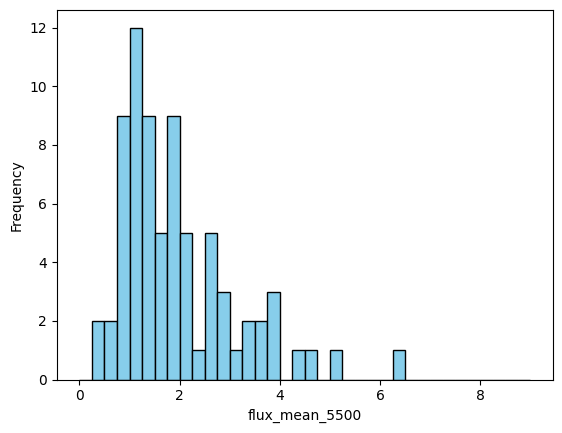

In [83]:
# Create the histogram
plt.hist(df_best['flux_mean_5500'], bins=np.linspace(0, 9, 37), color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('flux_mean_5500')
plt.ylabel('Frequency')
#plt.title('')

plt.show()

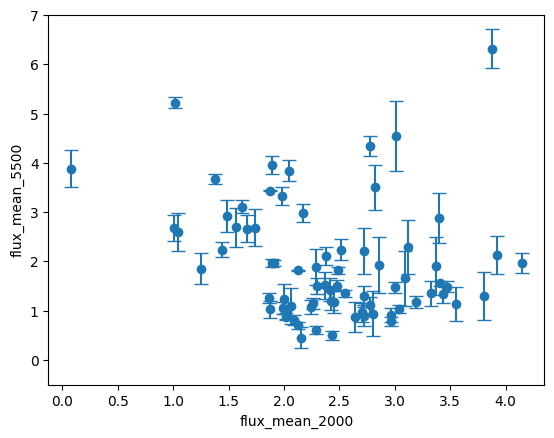

In [84]:
plt.errorbar(df_best['flux_mean_2000'], df_best['flux_mean_5500'], yerr=df_best['err_mean_5500'], #xerr=df_best['err_mean_2000'], 
             fmt='o', capsize=5)
plt.ylim(-0.5,7)
plt.xlabel('flux_mean_2000')
plt.ylabel('flux_mean_5500')
plt.show()

## Definindo os grupos

In [85]:
bins = [0, 1.25, 2.5, 3.75, 5, 18.5]
labels = ["G1", "G2", "G3", "G4", 'G5']

df_best['grupos'] = pd.cut(df_best['flux_mean_5500'], bins=bins, labels=labels)

df_best["grupos"].value_counts()

grupos
G2    29
G1    25
G3    13
G4     5
G5     3
Name: count, dtype: int64

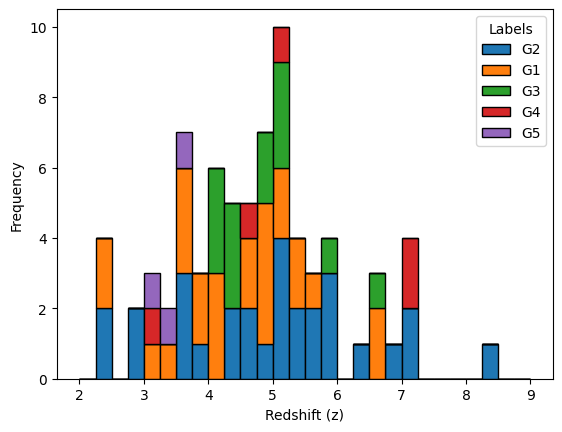

In [86]:
# Separar os dados por grupo (label)
grupos = df_best['grupos'].unique()
dados_por_grupo = [df_best[df_best['grupos'] == grupo]['z'] for grupo in grupos]


# Create the histogram
plt.hist(dados_por_grupo, bins=np.linspace(2, 9, 29), stacked=True, label=grupos, edgecolor='black')

# Add labels and title
plt.xlabel('Redshift (z)')
plt.ylabel('Frequency')
plt.legend(title='Labels')
#plt.title('')

plt.show()

In [87]:

df_best["grupo_num"] = df_best["grupos"].map({
    "G1": 1,
    "G2": 2,
    "G3": 3,
    "G4": 4,
    "G5": 5
})

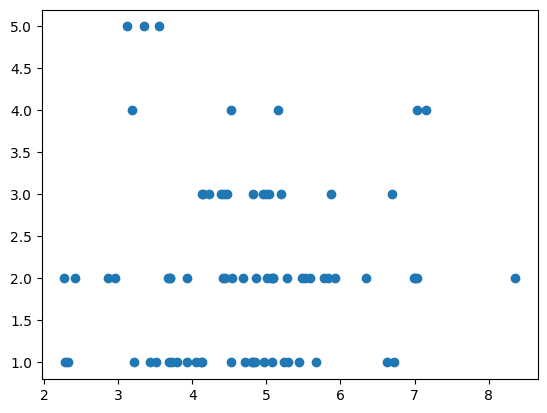

In [105]:

plt.scatter(df_best['z'], df_best['grupo_num'])
plt.show()

### Casos especiais

In [103]:
linhas_a = df_best[df_best['grupos'] == 'G5']
linhas_a

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,group_id,grupos,grupo_num
54,rubies-uds1-v4_prism-clear_4233_40579.spec.fits,3.113558,True,7.074874e-20,0.3446,0.3646,None,0.119387,0.120747,5.218966,0.110583,1.018880,0.392648,47.195155,34.244200,-5.245871,3.113558,0,None,None,None,None,"(None, rubies-uds1-v4_prism-clear_4233_40579.s...",G5,5
58,rubies-uds23-v4_prism-clear_4233_144195.spec.fits,3.354755,True,1.154061e-20,0.3446,0.3646,None,0.748337,0.724885,6.316134,0.397383,3.880742,2.308169,15.894337,34.325156,-5.143685,3.354755,0,None,None,None,None,"(None, rubies-uds23-v4_prism-clear_4233_144195...",G5,5


In [102]:
new_cats = ['The Cliff', 'uncover_2561_20698']
df_best['grupos'] = df_best['grupos'].cat.add_categories(
    [c for c in new_cats if c not in df_best['grupos'].cat.categories]
)

## The Cliff
df_best.loc[df_best['file'] == 'rubies-uds31-v4_prism-clear_4233_154183.spec.fits', 'grupos'] = 'The Cliff'

## uncover_2561_20698
df_best.loc[df_best['file'] == 'uncover-61-v4_prism-clear_2561_20698.spec.fits', 'grupos'] = 'uncover_2561_20698'

In [104]:
df_best["grupos"].value_counts()

grupos
G2                    28
G1                    25
G3                    13
G4                     5
G5                     2
The Cliff              1
uncover_2561_20698     1
Name: count, dtype: int64

### Listas dos grupos

In [106]:
g1_df = df_best[df_best['grupos']=='G1']
g2_df = df_best[df_best['grupos']=='G2']
g3_df = df_best[df_best['grupos']=='G3']
g4_df = df_best[df_best['grupos']=='G4']
g5_df = df_best[df_best['grupos']=='G5']

g1_zip = list(zip(g1_df['file'], g1_df['z']))
g2_zip = list(zip(g2_df['file'], g2_df['z']))
g3_zip = list(zip(g3_df['file'], g3_df['z']))
g4_zip = list(zip(g4_df['file'], g4_df['z']))
g5_zip = list(zip(g5_df['file'], g5_df['z']))

g1_zip_zsorted = sorted(g1_zip, key=lambda x: x[1])
g2_zip_zsorted = sorted(g2_zip, key=lambda x: x[1])
g3_zip_zsorted = sorted(g3_zip, key=lambda x: x[1])
g4_zip_zsorted = sorted(g4_zip, key=lambda x: x[1])
g5_zip_zsorted = sorted(g5_zip, key=lambda x: x[1])


In [107]:
## lista dos objetos com z < 2.5 para plotar os espectros
low_z = df_best[df_best['z'] < 2.5]
low_z_zip = list(zip(low_z['file'], low_z['z'])) 

## lista dos objetos com SNR < 2 ou erro em 5500 > 1.1 para plotar os espectros
ruido_zip = list(zip(df_retirado['file'], df_retirado['z']))

### Gráficos para os diferentes grupos

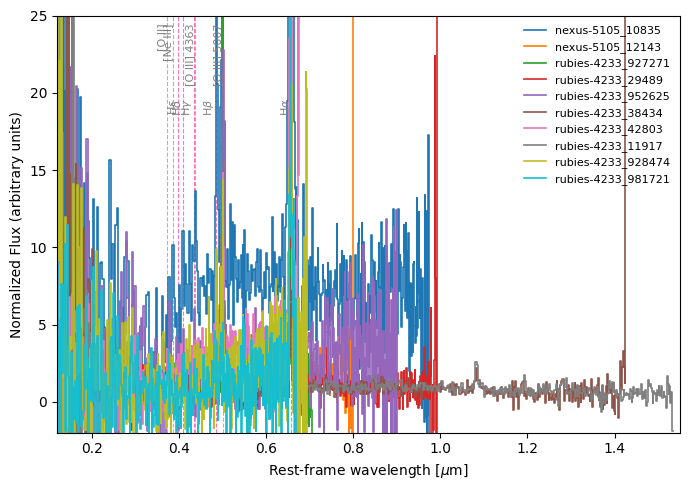

In [91]:
fig = plot_overlaid_spectra(
    ruido_zip,
    indices=range(10, 20),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

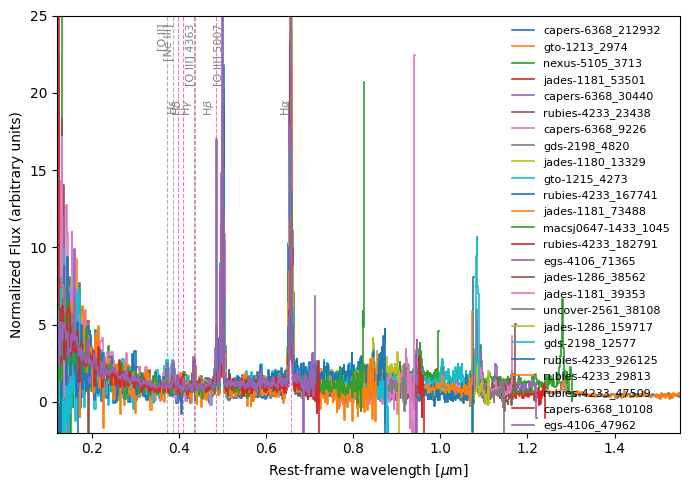

In [109]:
fig = plot_overlaid_spectra(
    g1_zip_zsorted,
    indices=range(0, 25),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

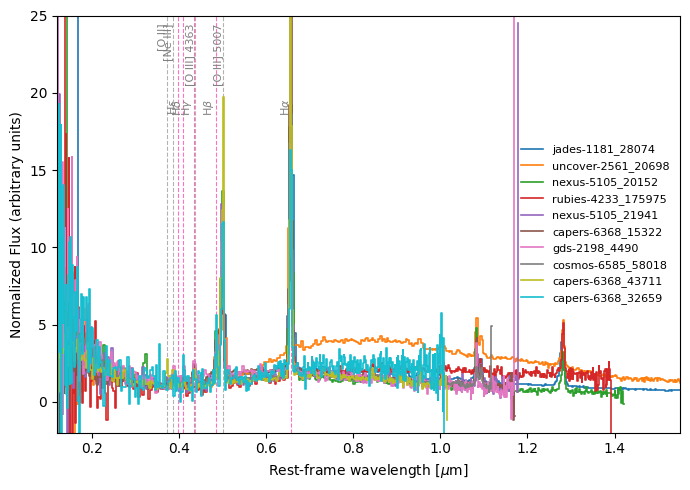

In [93]:
fig = plot_overlaid_spectra(
    g2_zip_zsorted,
    indices=range(0, 10),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

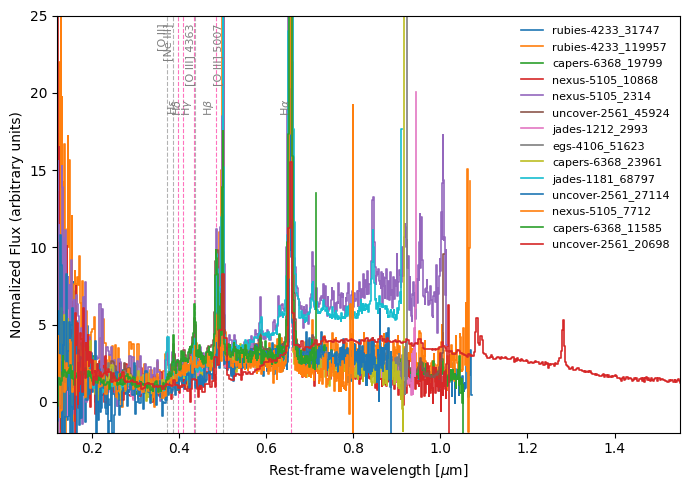

In [146]:
fig = plot_overlaid_spectra(
    g3_zip_zsorted +[('uncover-61-v4_prism-clear_2561_20698.spec.fits',2.417316)],
    indices=range(0, 14),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

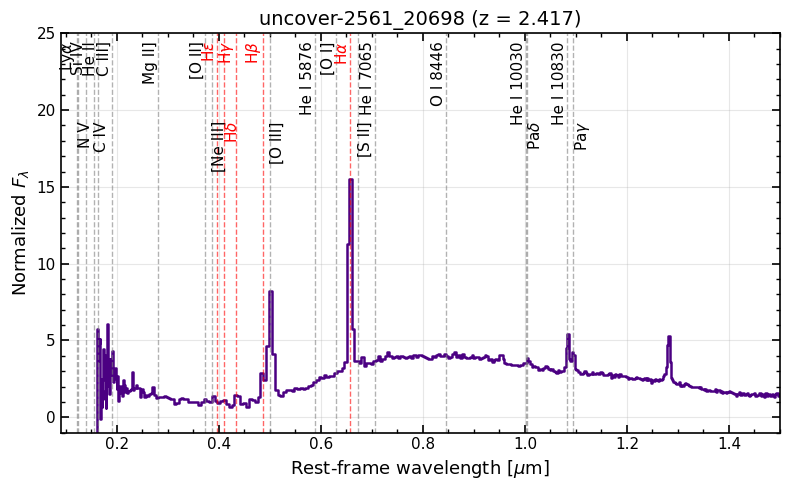

In [95]:
lines = {
    r"Ly$\alpha$": 0.121567,
    r"N V": 0.1240,
    r"Si IV": 0.140277,
    r"C IV": 0.1549,
    r"He II": 0.1640,
    r"C III]": 0.1909,
    r"Mg II]": 0.2800,
    r"[O II]": 0.3727,
    r"[Ne III]": 0.386876,
    r"H$\epsilon$": 0.3970079,
    r"H$\delta$": 0.4101742,
    r"H$\gamma$": 0.4340471,
    r"H$\beta$": 0.48613,
    r"[O III]": 0.5006843,
    r"He I 5876": 0.5875624,
    r"[O I]": 0.6300,
    r"H$\alpha$": 0.6563,
    r"[S II]": 0.6723,
    r"He I 7065": 0.7065,
    r"O I 8446": 0.8446,
    r"He I 10030": 1.0030,
    r"Pa$\delta$": 1.0049,
    r"He I 10830": 1.0830,
    r"Pa$\gamma$": 1.0938,
}

fig, ax = plot_spectrum_presentation(
    fname="uncover-61-v4_prism-clear_2561_20698.spec.fits",
    z=2.417316,
    lines=lines,
    loader_kwargs=dict(normalize=True),
    spectrum_kwargs=dict(color='indigo', lw=1.8, where="mid"),
    xlim=(0.09,1.5),
    ylim=(-1,25)
)

fig.savefig('Figuras/jades-1180_12402.pdf')

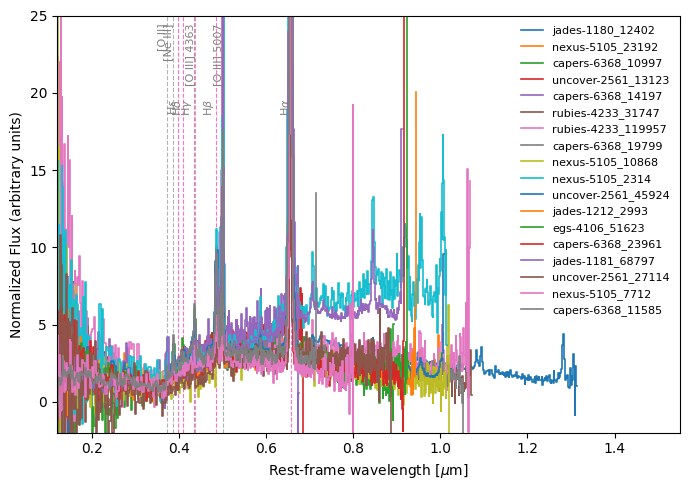

In [96]:
fig = plot_overlaid_spectra(
    g4_zip_zsorted + g3_zip_zsorted, #+ [('uncover-61-v4_prism-clear_2561_20698.spec.fits',2.417316)],
    indices=range(0, 18),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

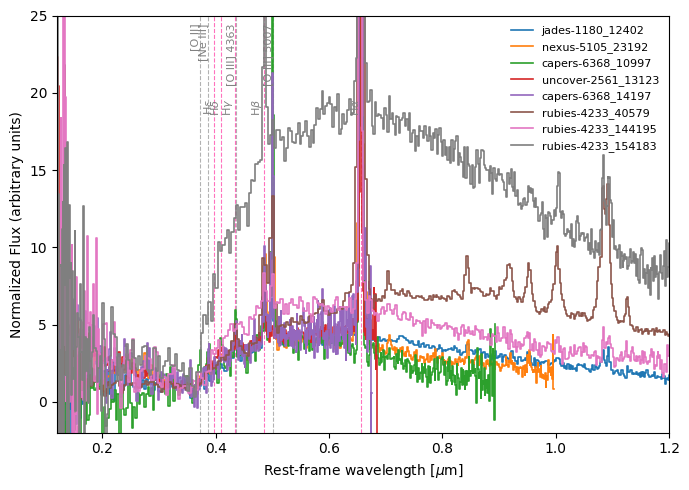

In [97]:
fig = plot_overlaid_spectra(
    g4_zip_zsorted + g5_zip_zsorted, #+ [('uncover-61-v4_prism-clear_2561_20698.spec.fits',2.417316)],
    indices=range(0, 8),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.2),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

# Calculando o espectro médio de cada grupo

In [156]:
def build_mean_specs(
    grupos_dict,
    base_path="DeGraaff_espectros",
    n_clip_end=10,
    load_kwargs=None
):
    """
    Build mean spectra for multiple groups.

    Parameters
    ----------
    grupos_dict : dict
        {"G1": [(file, z), ...], "G2": [...], ...}
    load_kwargs : dict or None
        kwargs for load_spectrum()

    Returns
    -------
    mean_specs : dict
        {"G1": mean_spec, "G2": mean_spec, ...}
    """

    if load_kwargs is None:
        load_kwargs = dict(
            restframe=True,
            normalize=True,
            norm_window=(0.3446, 0.3646)
        )

    mean_specs = {}

    for nome, grupo in grupos_dict.items():

        spectra = []

        for file, z in grupo:
            try:
                spec = load_spectrum(
                    f"{base_path}/{file}",
                    z=z,
                    **load_kwargs
                )
                spectra.append(spec)

            except Exception as e:
                print(f"Skipping {file} → {e}")

        if len(spectra) == 0:
            print(f"{nome} vazio!")
            continue

        mean_spec = compute_mean_spectrum(
            spectra,
            n_clip_end=n_clip_end
        )

        mean_specs[nome] = mean_spec

        print(f"{nome}: N = {mean_spec['n_objects']}")

    return mean_specs

In [157]:
grupos = {
    "G1": g1_zip_zsorted,
    "G2": g2_zip_zsorted,
    "G3": g3_zip_zsorted,
    "G4": g4_zip_zsorted,
    "G5": g5_zip_zsorted,
}

mean_specs = build_mean_specs(grupos)

<string>:55: RuntimeWarning: Mean of empty slice
/home/bruna/Documentos/Doutorado/LRDs/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<string>:61: RuntimeWarning: Mean of empty slice


G1: N = 25
G2: N = 28
G3: N = 13
G4: N = 5
G5: N = 2


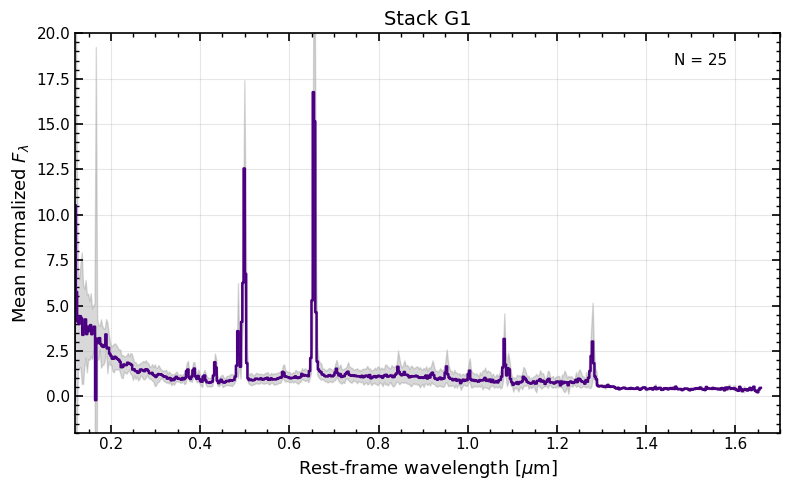

In [158]:
fig = plot_mean_spectrum(
    mean_specs['G1'],
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G1",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

plt.show()

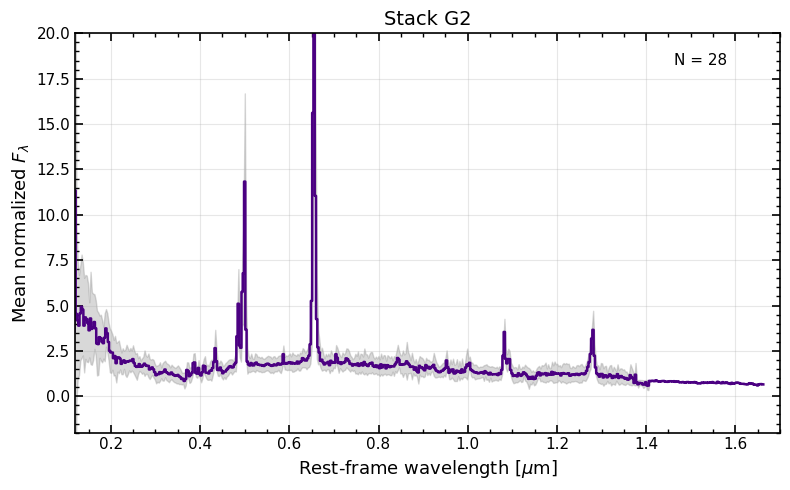

In [159]:
fig = plot_mean_spectrum(
    mean_specs['G2'],
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G2",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

plt.show()

In [141]:
spectra_G3 = [
    load_spectrum(f"DeGraaff_espectros/{file}", z=z, restframe=True, normalize=True, norm_window=(0.3446,0.3646))
    for file, z in g3_zip_zsorted
]

mean_spec_g3 = compute_mean_spectrum(
    spectra_G3,
    n_clip_end=15  # corta bordas ruidosas
)
print(mean_spec_g3['n_objects'])

13


<string>:55: RuntimeWarning: Mean of empty slice
/home/bruna/Documentos/Doutorado/LRDs/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<string>:61: RuntimeWarning: Mean of empty slice


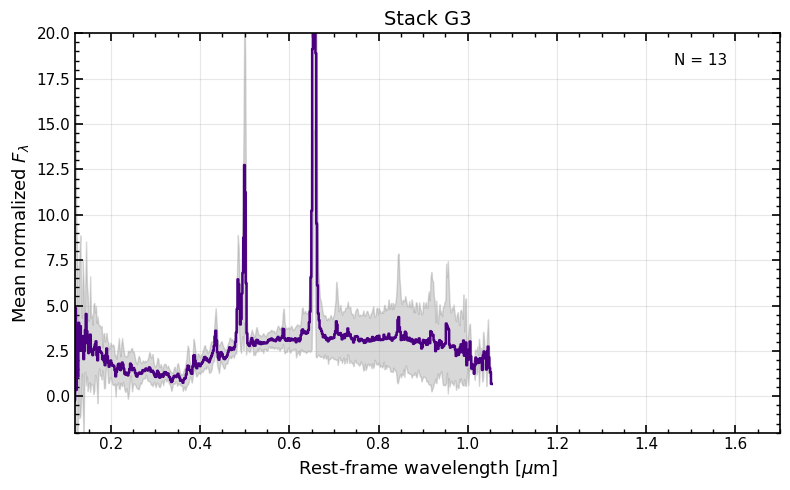

In [149]:
fig = plot_mean_spectrum(
    mean_spec_g3,
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G3",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

plt.show()

In [147]:
spectra_G4 = [
    load_spectrum(f"DeGraaff_espectros/{file}", z=z, restframe=True, normalize=True, norm_window=(0.3446,0.3646))
    for file, z in g4_zip_zsorted
]

mean_spec_g4 = compute_mean_spectrum(
    spectra_G4,
    n_clip_end=15  # corta bordas ruidosas
)
print(mean_spec_g4['n_objects'])

5


<string>:55: RuntimeWarning: Mean of empty slice
/home/bruna/Documentos/Doutorado/LRDs/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<string>:61: RuntimeWarning: Mean of empty slice


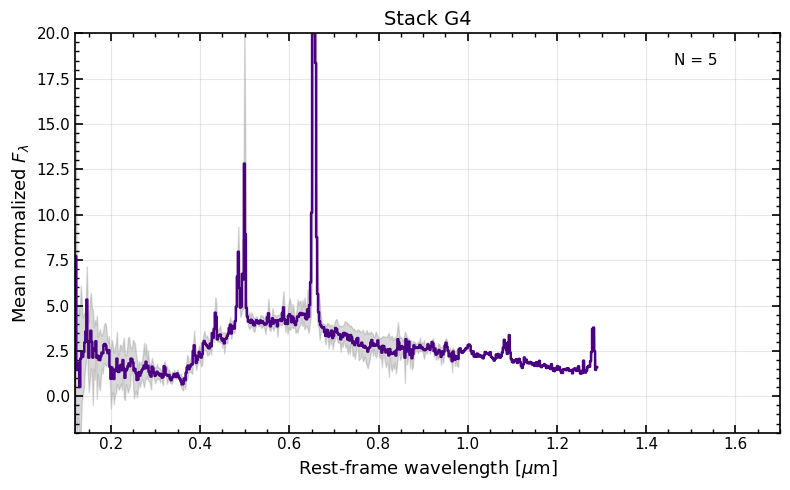

In [148]:
fig = plot_mean_spectrum(
    mean_spec_g4,
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G4",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

plt.show()

In [150]:
spectra_G5 = [
    load_spectrum(f"DeGraaff_espectros/{file}", z=z, restframe=True, normalize=True, norm_window=(0.3446,0.3646))
    for file, z in g5_zip_zsorted
]

mean_spec_g5 = compute_mean_spectrum(
    spectra_G5,
    n_clip_end=15  # corta bordas ruidosas
)
print(mean_spec_g5['n_objects'])

2


<string>:55: RuntimeWarning: Mean of empty slice
/home/bruna/Documentos/Doutorado/LRDs/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<string>:61: RuntimeWarning: Mean of empty slice


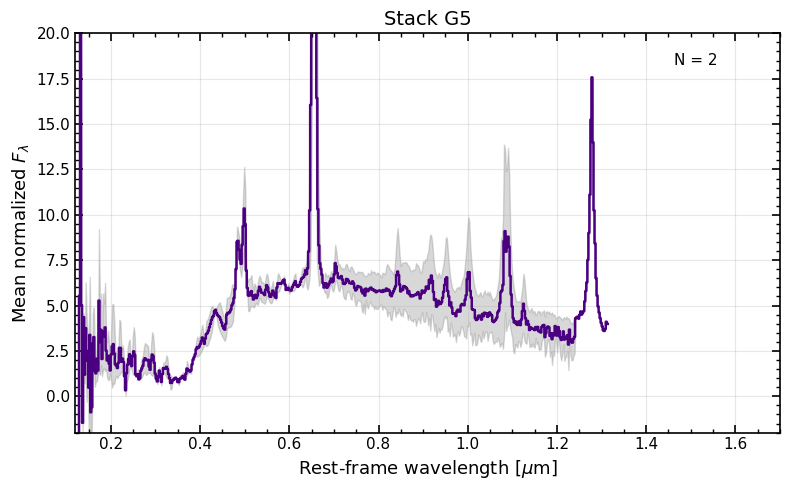

In [151]:
fig = plot_mean_spectrum(
    mean_spec_g5,
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G5",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

plt.show()